# MOFA+ Baseline — Multi-Omics Factor Analysis

MOFA+ is the standard classical method for multi-omics integration.
We compare it against our foundation model approach.


In [2]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


In [3]:
!pip install -q mofapy2 anndata numpy pandas scikit-learn xgboost umap-learn matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 63.1 MB/s eta 0:00:00


In [6]:
from pathlib import Path

# Data is in the copied/shortcut folder
INPUT_ROOT = Path("/content/drive/MyDrive/multiomics-project")

# MOFA results should be written to the shared results folder
OUTPUT_ROOT = Path("/content/drive/MyDrive/multiomics-project")

METH_H5AD = INPUT_ROOT / "data/processed/tcga_methylation.h5ad"
RNA_H5AD  = INPUT_ROOT / "data/processed/tcga_rna_seq.h5ad"

# Try possible manifest locations
MANIFEST_CANDIDATES = [
    INPUT_ROOT / "manifests/matched_samples.csv",
    INPUT_ROOT / "data/manifests/matched_samples.csv",
    INPUT_ROOT / "data/processed/matched_samples.csv",
    OUTPUT_ROOT / "manifests/matched_samples.csv",
    OUTPUT_ROOT / "data/manifests/matched_samples.csv",
]

MANIFEST = None
for p in MANIFEST_CANDIDATES:
    if p.exists():
        MANIFEST = p
        break

# If not found in the common places, search both project folders
if MANIFEST is None:
    for root in [INPUT_ROOT, OUTPUT_ROOT]:
        matches = list(root.rglob("matched_samples.csv"))
        if matches:
            MANIFEST = matches[0]
            break

if MANIFEST is None:
    raise FileNotFoundError(
        "matched_samples.csv was not found. Run: "
        '!find "/content/drive/MyDrive" -name "matched_samples.csv" 2>/dev/null'
    )

OUTPUT_DIR = OUTPUT_ROOT / "results/mofa"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

N_FACTORS = 30
N_HVG     = 2000
N_HVM     = 5000

print("Methylation h5ad:", METH_H5AD.exists(), METH_H5AD)
print("RNA h5ad        :", RNA_H5AD.exists(), RNA_H5AD)
print("Manifest        :", MANIFEST.exists(), MANIFEST)
print("Output dir      :", OUTPUT_DIR.exists(), OUTPUT_DIR)

Methylation h5ad: True /content/drive/MyDrive/multiomics-project/data/processed/tcga_methylation.h5ad
RNA h5ad        : True /content/drive/MyDrive/multiomics-project/data/processed/tcga_rna_seq.h5ad
Manifest        : True /content/drive/MyDrive/multiomics-project/data/manifests/matched_samples.csv
Output dir      : True /content/drive/MyDrive/multiomics-project/results/mofa


In [7]:
import numpy as np
import pandas as pd
import anndata as ad
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize
import xgboost as xgb

print('Loading data...')
adata_meth = ad.read_h5ad(METH_H5AD)
adata_rna  = ad.read_h5ad(RNA_H5AD)
manifest   = pd.read_csv(MANIFEST)

print(f'Methylation: {adata_meth.shape}')
print(f'RNA-seq    : {adata_rna.shape}')

X_meth = adata_meth.X if isinstance(adata_meth.X, np.ndarray) else adata_meth.X.toarray()
X_rna  = adata_rna.X  if isinstance(adata_rna.X,  np.ndarray) else adata_rna.X.toarray()

# Select top variable features
top_meth = np.argsort(np.var(X_meth, axis=0))[-N_HVM:]
top_rna  = np.argsort(np.var(X_rna,  axis=0))[-N_HVG:]
X_meth_sel = X_meth[:, top_meth]  # (800, 5000)
X_rna_sel  = X_rna[:, top_rna]    # (800, 2000)

# Standardize
X_meth_sel = StandardScaler().fit_transform(X_meth_sel)
X_rna_sel  = StandardScaler().fit_transform(X_rna_sel)

labels = manifest['project'].values
le     = LabelEncoder()
y      = le.fit_transform(labels)

print(f'Cancer types: {dict(zip(*np.unique(labels, return_counts=True)))}')

Loading data...
Methylation: (800, 49156)
RNA-seq    : (800, 60616)
Cancer types: {'TCGA-BRCA': np.int64(134), 'TCGA-COAD': np.int64(133), 'TCGA-KIRC': np.int64(133), 'TCGA-LIHC': np.int64(133), 'TCGA-LUAD': np.int64(134), 'TCGA-THCA': np.int64(133)}


In [13]:
import numpy as np
import pandas as pd
import anndata as ad

from pathlib import Path
from mofapy2.run.entry_point import entry_point

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier


N_HVM = 100
N_HVG = 50
N_FACTORS = 5

print("Loading data...")

adata_meth = ad.read_h5ad(METH_H5AD)
adata_rna = ad.read_h5ad(RNA_H5AD)
manifest = pd.read_csv(MANIFEST)

print("Methylation:", adata_meth.shape)
print("RNA-seq    :", adata_rna.shape)

X_meth = adata_meth.X if isinstance(adata_meth.X, np.ndarray) else adata_meth.X.toarray()
X_rna = adata_rna.X if isinstance(adata_rna.X, np.ndarray) else adata_rna.X.toarray()

label_col = None
for col in ["cancer_type", "Cancer type", "project_id", "project", "disease", "label"]:
    if col in manifest.columns:
        label_col = col
        break

if label_col is None:
    print("Manifest columns:", manifest.columns.tolist())
    raise ValueError("Could not find label column. Set y manually from manifest.")

y = manifest[label_col].values

print("Using label column:", label_col)
print("Cancer types:", dict(pd.Series(y).value_counts()))

assert X_meth.shape[0] == X_rna.shape[0] == len(y)

print("Selecting feature set...")

top_meth = np.argsort(np.var(X_meth, axis=0))[-N_HVM:]
top_rna = np.argsort(np.var(X_rna, axis=0))[-N_HVG:]

X_meth_sel = X_meth[:, top_meth]
X_rna_sel = X_rna[:, top_rna]

X_meth_sel = np.asarray(X_meth_sel)
X_rna_sel = np.asarray(X_rna_sel)

print("Selected methylation shape:", X_meth_sel.shape)
print("Selected RNA shape:", X_rna_sel.shape)

print("Running MOFA+...")

ent = entry_point()

ent.set_data_options(
    scale_groups=False,
    scale_views=True
)

ent.set_data_matrix(
    [[X_rna_sel], [X_meth_sel]],
    likelihoods=["gaussian", "gaussian"],
    views_names=["RNA", "Methylation"],
    groups_names=["TCGA"]
)

ent.set_model_options(
    factors=N_FACTORS,
    spikeslab_weights=True,
    ard_factors=True,
    ard_weights=True
)

ent.set_train_options(
    iter=1000,
    convergence_mode="fast",
    seed=42,
    verbose=True
)

ent.build()
ent.run()

Z = ent.model.nodes["Z"].getExpectation()

print("Raw Z shape:", Z.shape)

mofa_embedding = Z

if mofa_embedding.shape[0] == N_FACTORS and mofa_embedding.shape[1] == X_rna_sel.shape[0]:
    mofa_embedding = mofa_embedding.T

print("Final MOFA embedding shape:", mofa_embedding.shape)

assert mofa_embedding.shape == (X_rna_sel.shape[0], N_FACTORS)

OUTPUT_DIR = Path(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

np.save(OUTPUT_DIR / "mofa_embedding.npy", mofa_embedding)

print("Saved:", OUTPUT_DIR / "mofa_embedding.npy")

print("Evaluating MOFA+ with XGBoost...")

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
class_names = [str(c) for c in label_encoder.classes_]

X_train, X_test, y_train, y_test = train_test_split(
    mofa_embedding,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

mofa_xgb = XGBClassifier(
    n_estimators=50,
    max_depth=2,
    learning_rate=0.03,
    subsample=0.7,
    colsample_bytree=0.7,
    objective="multi:softprob",
    num_class=len(class_names),
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

mofa_xgb.fit(X_train, y_train)

y_pred = mofa_xgb.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average="macro")
f1_weighted = f1_score(y_test, y_pred, average="weighted")
precision_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)
recall_macro = recall_score(y_test, y_pred, average="macro", zero_division=0)

print()
print("MOFA+ + XGBoost Evaluation Results")
print("---------------------------------------")
print(f"Accuracy:          {acc:.4f}")
print(f"Macro F1:          {f1_macro:.4f}")
print(f"Weighted F1:       {f1_weighted:.4f}")
print(f"Macro Precision:   {precision_macro:.4f}")
print(f"Macro Recall:      {recall_macro:.4f}")

print("\nClassification report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=class_names,
    zero_division=0
))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

Loading data...
Methylation: (800, 49156)
RNA-seq    : (800, 60616)
Using label column: project
Cancer types: {'TCGA-BRCA': np.int64(134), 'TCGA-LUAD': np.int64(134), 'TCGA-COAD': np.int64(133), 'TCGA-KIRC': np.int64(133), 'TCGA-LIHC': np.int64(133), 'TCGA-THCA': np.int64(133)}
Selecting feature set...
Selected methylation shape: (800, 100)
Selected RNA shape: (800, 50)
Running MOFA+...

        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
         


In [14]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)


mofa_embedding = np.load(OUTPUT_DIR / "mofa_embedding.npy")

print("MOFA embedding shape:", mofa_embedding.shape)

assert mofa_embedding.shape[0] == len(y), (
    f"Mismatch: embedding has {mofa_embedding.shape[0]} samples, "
    f"but labels have {len(y)} samples"
)


label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Classes:", list(label_encoder.classes_))
print("Number of classes:", len(label_encoder.classes_))


X_train, X_test, y_train, y_test = train_test_split(
    mofa_embedding,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

clf = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=42
    ))
])

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)


acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average="macro")
f1_weighted = f1_score(y_test, y_pred, average="weighted")
precision_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)
recall_macro = recall_score(y_test, y_pred, average="macro", zero_division=0)

print("MOFA+ Evaluation Results")
print("------------------------")
print(f"Accuracy:          {acc:.4f}")
print(f"Macro F1:          {f1_macro:.4f}")
print(f"Weighted F1:       {f1_weighted:.4f}")
print(f"Macro Precision:   {precision_macro:.4f}")
print(f"Macro Recall:      {recall_macro:.4f}")

print("\nClassification report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_,
    zero_division=0
))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

MOFA embedding shape: (800, 5)
Classes: ['TCGA-BRCA', 'TCGA-COAD', 'TCGA-KIRC', 'TCGA-LIHC', 'TCGA-LUAD', 'TCGA-THCA']
Number of classes: 6
MOFA+ Evaluation Results
------------------------
Accuracy:          0.7000
Macro F1:          0.6962
Weighted F1:       0.6949
Macro Precision:   0.7044
Macro Recall:      0.7013

Classification report:
              precision    recall  f1-score   support

   TCGA-BRCA       0.67      0.52      0.58        27
   TCGA-COAD       0.51      0.74      0.61        27
   TCGA-KIRC       0.70      0.62      0.65        26
   TCGA-LIHC       1.00      0.96      0.98        27
   TCGA-LUAD       0.45      0.37      0.41        27
   TCGA-THCA       0.90      1.00      0.95        26

    accuracy                           0.70       160
   macro avg       0.70      0.70      0.70       160
weighted avg       0.70      0.70      0.69       160


Confusion matrix:
[[14  7  2  0  4  0]
 [ 4 20  0  0  3  0]
 [ 1  2 16  0  5  2]
 [ 0  0  1 26  0  0]
 [ 2 10  4

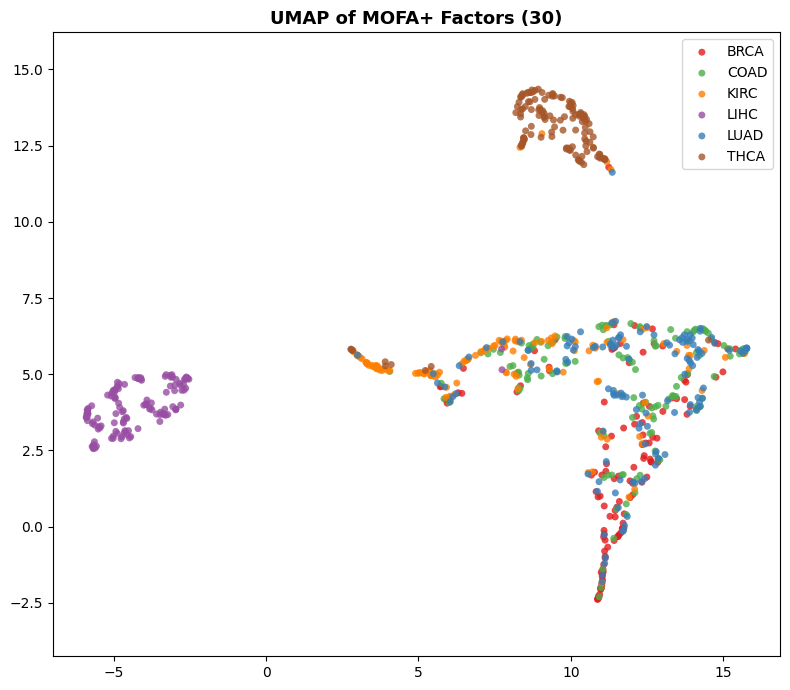

Done! Compare this UMAP to Geneformer/MethylGPT — foundation models should be cleaner.


In [15]:
# UMAP of MOFA factors colored by cancer type
import umap
import matplotlib.pyplot as plt

CANCER_COLORS = {'TCGA-BRCA':'#e41a1c','TCGA-LUAD':'#377eb8','TCGA-COAD':'#4daf4a',
                 'TCGA-KIRC':'#ff7f00','TCGA-LIHC':'#984ea3','TCGA-THCA':'#a65628'}

reducer   = umap.UMAP(n_components=2, random_state=42, n_neighbors=15)
embedding = reducer.fit_transform(mofa_embedding)

fig, ax = plt.subplots(figsize=(8, 7))
for cancer in np.unique(labels):
    mask = labels == cancer
    ax.scatter(embedding[mask,0], embedding[mask,1],
               c=CANCER_COLORS.get(cancer,'#333'), label=cancer.replace('TCGA-',''),
               s=25, alpha=0.8, edgecolors='none')
ax.set_title('UMAP of MOFA+ Factors (30)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10); ax.set_aspect('equal','datalim')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'umap_mofa.png', dpi=150, bbox_inches='tight')
plt.show()
print('Done! Compare this UMAP to Geneformer/MethylGPT — foundation models should be cleaner.')